# 04 · CatBoost - ordered boosting & native categoricals

CatBoost's distinctive ideas:

1. **Native categorical handling** via *ordered target statistics* - it encodes a
   category using the target, but only from rows seen *earlier* in a random
   permutation, which avoids target leakage.
2. **Ordered boosting.** The same leakage-avoidance applied to the boosting
   process itself, which helps a lot on smaller datasets.
3. **Symmetric (oblivious) trees.** Every node at a given depth uses the *same*
   split - fast inference and a built-in regularizer.

In [ ]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
from utils import data as D
from utils import plotting as P
from sklearn.metrics import root_mean_squared_error, r2_score

df = pd.read_parquet("../data/regression.parquet")
y = df.pop("target")
X = df                                        # keeps 'category' as a categorical dtype
Xtr, Xte, ytr, yte = D.train_test_split_df(X, y, test_size=0.25, seed=0)


In [ ]:
from catboost import CatBoostRegressor, Pool

cat_features = ["category"]
train_pool = Pool(Xtr, ytr, cat_features=cat_features)
test_pool  = Pool(Xte, yte, cat_features=cat_features)

model = CatBoostRegressor(
    iterations=600, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
    random_seed=0, verbose=0, eval_metric="RMSE", early_stopping_rounds=40,
)
model.fit(train_pool, eval_set=test_pool)
print("best iteration:", model.get_best_iteration())
print("test RMSE:", round(root_mean_squared_error(yte, model.predict(Xte)), 3),
      "| R2:", round(r2_score(yte, model.predict(Xte)), 3))

best iteration: 599
test RMSE: 1.212 | R2: 0.949


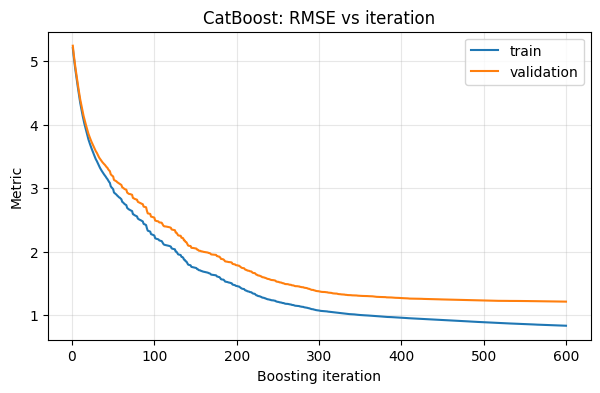

In [ ]:
ev = model.get_evals_result()
P.plot_training_curve({"train": ev["learn"]["RMSE"],
                       "validation": ev["validation"]["RMSE"]},
                      title="CatBoost: RMSE vs iteration")
plt.show()

## Ordered vs plain boosting

Ordered boosting shines on small data where leakage causes overfitting. Train
both modes on a *small* subset and compare validation error.

In [ ]:
small = slice(0, 600)
res = {}
for mode in ["Ordered", "Plain"]:
    m = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=6,
                          boosting_type=mode, random_seed=0, verbose=0)
    m.fit(Pool(Xtr.iloc[small], ytr.iloc[small], cat_features=cat_features))
    res[mode] = root_mean_squared_error(yte, m.predict(Xte))
print({k: round(v, 3) for k, v in res.items()})
print("Lower is better - Ordered usually wins on small data.")

{'Ordered': 2.218, 'Plain': 1.863}
Lower is better - Ordered usually wins on small data.


## Importance & native categorical effect

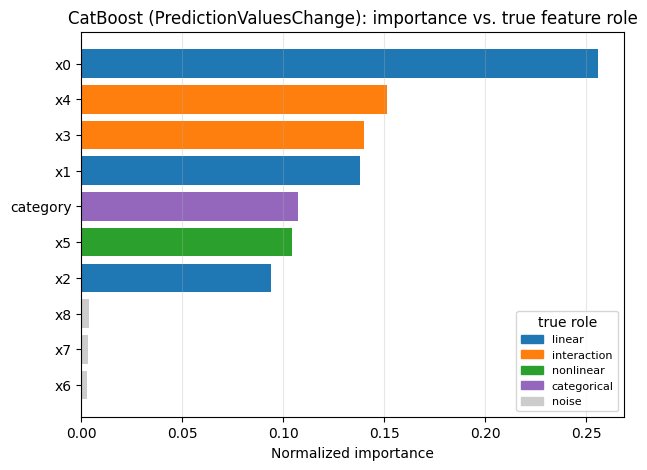

In [ ]:
_, _, gt = D.make_dataset("regression", n_samples=4000, seed=42)
imp = dict(zip(X.columns, model.get_feature_importance(train_pool)))
P.plot_importance_vs_truth(imp, gt, model_name="CatBoost (PredictionValuesChange)")
plt.show()

   mean_SHAP  true_effect (centred)
A       2.32                    3.0
B      -1.49                   -1.0
C      -0.50                    0.5
D      -2.98                   -2.5


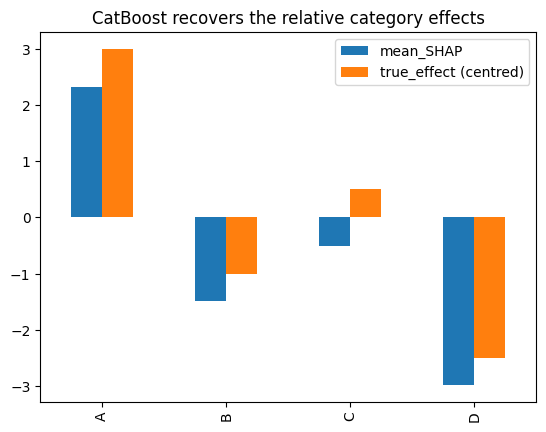

In [ ]:
# CatBoost learned the category effects without any manual encoding.
import shap
expl = shap.TreeExplainer(model)
sv = expl.shap_values(test_pool)
jc = list(X.columns).index("category")
dfc = pd.DataFrame({"category": Xte["category"].values, "shap_category": sv[:, jc]})
order = ["A", "B", "C", "D"]
means = dfc.groupby("category", observed=True)["shap_category"].mean().reindex(order)
truth = pd.Series(gt.category_effects).reindex(order)
comp = pd.DataFrame({"mean_SHAP": means, "true_effect (centred)": truth - truth.mean()})
print(comp.round(2))
comp.plot.bar(title="CatBoost recovers the relative category effects"); plt.show()

## Takeaways
- Best-in-class **out-of-the-box** on categorical data - just pass `cat_features`.
- **Ordered boosting** reduces overfitting, especially on small datasets.
- Symmetric trees give fast, regular models.

Next: **`05_ebm_explainable_boosting`**.